In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_PATH)

# TotalCharges should be numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df[df["TotalCharges"].isna()][
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [2]:
df = df.dropna(subset=["TotalCharges"]).copy()

print(df.shape)
print(df.isnull().sum().sum())

(7032, 21)
0


In [3]:
OUTPUT_PATH = PROJECT_ROOT / "data/processed/telco_churn_clean.csv"
df.to_csv(OUTPUT_PATH, index=False)

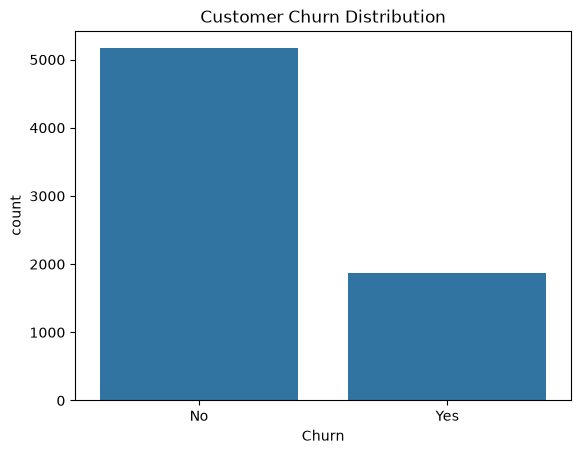

In [4]:
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.show()

In [5]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

In [6]:
categorical_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity",
    "PaperlessBilling"
]

for col in categorical_features:
    churn_rate = (
        df.groupby(col, observed=False)["Churn"]
        .apply(lambda x: (x == "Yes").mean())
        .sort_values(ascending=False)
    )

    print(f"\n{col}")
    print((churn_rate * 100).round(2))


Contract
Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Churn, dtype: float64

InternetService
InternetService
Fiber optic    41.89
DSL            19.00
No              7.43
Name: Churn, dtype: float64

PaymentMethod
PaymentMethod
Electronic check             45.29
Mailed check                 19.20
Bank transfer (automatic)    16.73
Credit card (automatic)      15.25
Name: Churn, dtype: float64

TechSupport
TechSupport
No                     41.65
Yes                    15.20
No internet service     7.43
Name: Churn, dtype: float64

OnlineSecurity
OnlineSecurity
No                     41.78
Yes                    14.64
No internet service     7.43
Name: Churn, dtype: float64

PaperlessBilling
PaperlessBilling
Yes    33.59
No     16.38
Name: Churn, dtype: float64


In [7]:
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

df.groupby("Churn")[numerical_features].median()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,38.0,64.45,1683.60
Yes,10.0,79.65,703.55


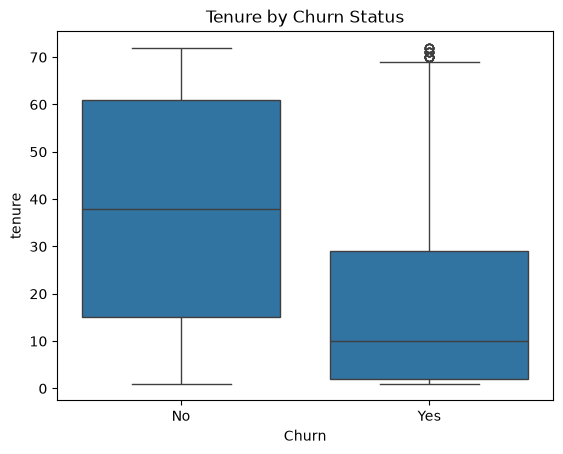

In [8]:
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure by Churn Status")
plt.show()

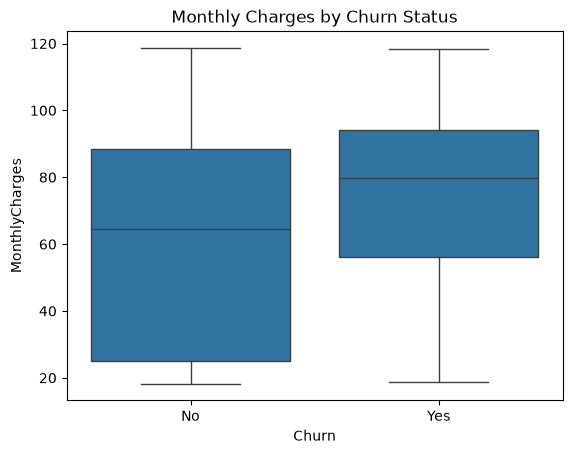

In [9]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn Status")
plt.show()

In [10]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


In [11]:
tenure_bins = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"],
    include_lowest=True
)

df.assign(TenureGroup=tenure_bins).groupby(
    "TenureGroup",
    observed=False
)["Churn"].apply(lambda x: (x == "Yes").mean() * 100)

TenureGroup
0-12     47.678161
13-24    28.710938
25-48    20.388959
49-72     9.513176
Name: Churn, dtype: float64